## Introduction to Quantum Information and Quantum Machine Learning lab 3 report
### Maciej Woś, 148276

In [16]:
import math
from numpy import pi
from qiskit import *
from qiskit.tools.jupyter import *
from qiskit.visualization import *
import pandas as pd

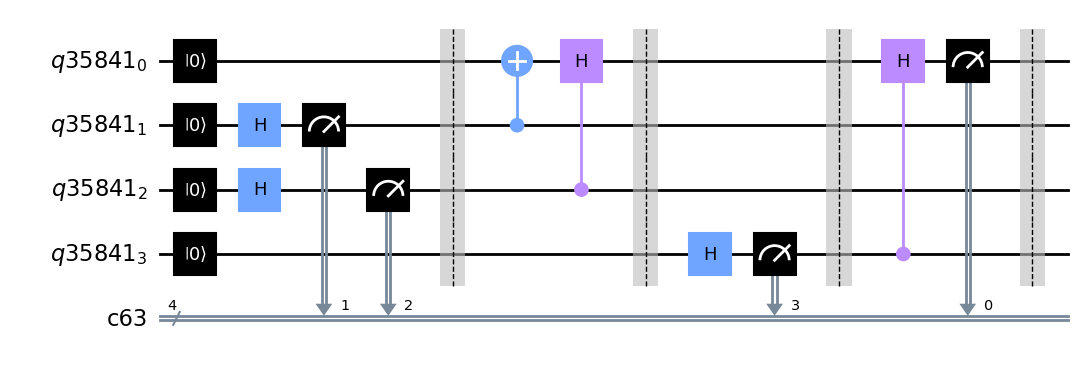

In [20]:
n0=4
q0 = QuantumRegister(n0)
c0 = ClassicalRegister(n0)
circuit0 = QuantumCircuit(q0, c0)
circuit0.reset([q0[0],q0[1],q0[2],q0[3]])
circuit0.h(q0[1])
circuit0.measure(q0[1],c0[1])
circuit0.h(q0[2])
circuit0.measure(q0[2],c0[2])
circuit0.barrier(q0[0], q0[1], q0[2], q0[3])
circuit0.cx(q0[1],q0[0])
circuit0.ch(q0[2],q0[0])
circuit0.barrier(q0[0], q0[1], q0[2], q0[3])
circuit0.h(q0[3])
circuit0.measure(q0[3],c0[3])
circuit0.barrier(q0[0], q0[1], q0[2], q0[3])
circuit0.ch(q0[3],q0[0])
circuit0.measure(q0[0], c0[0])
circuit0.barrier(q0[0], q0[1], q0[2], q0[3])
circuit0.draw(output= 'mpl')

In [24]:
backend = BasicAer.get_backend('qasm_simulator')
job_sim0 = execute(circuit0, backend, shots=1 )
sim_result0 = job_sim0.result()
wynik=sim_result0.get_counts(circuit0)
print(wynik)

{'0101': 1}


In [22]:
sample=10
bit=[]
for kk in range(sample):
    job_sim0 = execute(circuit0, backend, shots=1)
    sim_result0 = job_sim0.result()
    wynik=sim_result0.get_counts(circuit0)
    xA=int(list(wynik.keys())[0][2])
    yA=int(list(wynik.keys())[0][1])
    yB=int(list(wynik.keys())[0][0])
    xB=int(list(wynik.keys())[0][3])
    print(wynik,"->",[xA,yA,yB,xB])
    bit.append([xA,yA,yB,xB])
print(bit)

{'0011': 1} -> [1, 0, 0, 1]
{'0011': 1} -> [1, 0, 0, 1]
{'0011': 1} -> [1, 0, 0, 1]
{'0011': 1} -> [1, 0, 0, 1]
{'0111': 1} -> [1, 1, 0, 1]
{'1001': 1} -> [0, 0, 1, 1]
{'1011': 1} -> [1, 0, 1, 1]
{'0011': 1} -> [1, 0, 0, 1]
{'0000': 1} -> [0, 0, 0, 0]
{'0011': 1} -> [1, 0, 0, 1]
[[1, 0, 0, 1], [1, 0, 0, 1], [1, 0, 0, 1], [1, 0, 0, 1], [1, 1, 0, 1], [0, 0, 1, 1], [1, 0, 1, 1], [1, 0, 0, 1], [0, 0, 0, 0], [1, 0, 0, 1]]


In [23]:
kluczA=[]
kluczB=[]
for bb in bit:
    if bb[1]==bb[2]:
        kluczA.append(bb[0])
        kluczB.append(bb[3])
        print('yA=',bb[1], 'yB=',bb[2], '->','xA=',bb[0],',xB=',bb[3])
print('kluczA=',kluczA)
print('kluczB=',kluczB)
print(kluczA == kluczB)

yA= 0 yB= 0 -> xA= 1 ,xB= 1
yA= 0 yB= 0 -> xA= 1 ,xB= 1
yA= 0 yB= 0 -> xA= 1 ,xB= 1
yA= 0 yB= 0 -> xA= 1 ,xB= 1
yA= 0 yB= 0 -> xA= 1 ,xB= 1
yA= 0 yB= 0 -> xA= 0 ,xB= 0
yA= 0 yB= 0 -> xA= 1 ,xB= 1
kluczA= [1, 1, 1, 1, 1, 0, 1]
kluczB= [1, 1, 1, 1, 1, 0, 1]
True


In [19]:
def bb84_experiment(sample_size):
    n0 = 4
    q0 = QuantumRegister(n0)
    c0 = ClassicalRegister(n0)
    circuit0 = QuantumCircuit(q0, c0)

    circuit0.reset([q0[0], q0[1], q0[2], q0[3]])
    circuit0.h(q0[1])
    circuit0.measure(q0[1], c0[1])
    circuit0.h(q0[2])
    circuit0.measure(q0[2], c0[2])
    circuit0.barrier(q0[0], q0[1], q0[2], q0[3])
    circuit0.cx(q0[1], q0[0])
    circuit0.ch(q0[2], q0[0])
    circuit0.barrier(q0[0], q0[1], q0[2], q0[3])
    circuit0.h(q0[3])
    circuit0.measure(q0[3], c0[3])
    circuit0.barrier(q0[0], q0[1], q0[2], q0[3])
    circuit0.ch(q0[3], q0[0])
    circuit0.measure(q0[0], c0[0])
    circuit0.barrier(q0[0], q0[1], q0[2], q0[3])

    backend = BasicAer.get_backend('qasm_simulator')
    bit = []
    for _ in range(sample_size):
        job_sim0 = execute(circuit0, backend, shots=1)
        sim_result0 = job_sim0.result()
        wynik = sim_result0.get_counts(circuit0)
        xA = int(list(wynik.keys())[0][2])
        yA = int(list(wynik.keys())[0][1])
        yB = int(list(wynik.keys())[0][0])
        xB = int(list(wynik.keys())[0][3])
        bit.append([xA, yA, yB, xB])
        
    kluczA = []
    kluczB = []
    for bb in bit:
        if bb[1] == bb[2]:
            kluczA.append(bb[0])
            kluczB.append(bb[3])
    return len(kluczA)

sample_sizes = [16, 32, 64, 128, 256]
results = []

for sample_size in sample_sizes:
    test_results = []
    for _ in range(3):
        sifted_key_length = bb84_experiment(sample_size)
        test_results.append(sifted_key_length)
    results.append([sample_size] + test_results)

df = pd.DataFrame(results, columns=["Sample=n", "Test 1", "Test 2", "Test 3"])
df.style.set_caption("BB84 Key Sifting Results")

,Sample=n,Test 1,Test 2,Test 3
0,16,1,6,9
1,32,11,20,21
2,64,40,31,33
3,128,67,66,61
4,256,129,123,128
